## Day 1: Perimeter of an Ellipse

I had no better idea than to visualize the method of exhaustion.

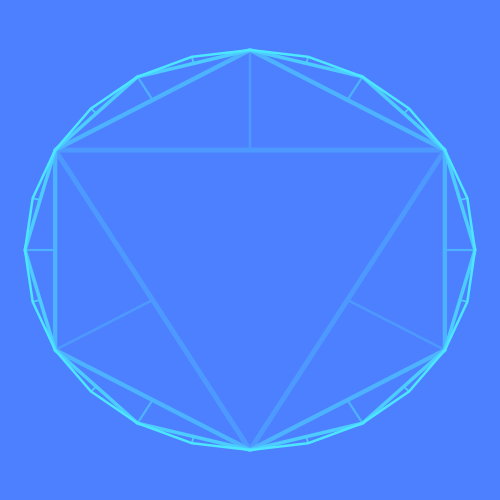

In [1]:
import io
import itertools
import math

import cairo
import IPython.display


svgio = io.BytesIO()
canvas_size = 500
base_stroke_width = 5

ellipse_radius_big = 225
ellipse_radius_small = 200
base_point_count = 3
level_count = 4


with cairo.SVGSurface(svgio, canvas_size, canvas_size) as surface:
    context = cairo.Context(surface)

    # Background
    context.rectangle(0, 0, canvas_size, canvas_size)
    context.set_source_rgb(0.3, 0.5, 1)
    context.fill()

    # Incribed polygons
    context.translate(canvas_size / 2, canvas_size / 2)

    for level in range(level_count):
        polygon_sides = base_point_count * 2 ** level
        angles = [(1 / 4 + i / polygon_sides) * 2 * math.pi for i in range(polygon_sides)]
        level_stroke_width = base_stroke_width * math.sqrt(1 - level / level_count)

        # Draw the polygon
        for angle in angles:
            context.line_to(ellipse_radius_big * math.cos(angle), ellipse_radius_small * math.sin(angle))

        context.set_line_width(level_stroke_width)
        context.set_source_rgb(0.3, 0.6 + 0.4 * (level / level_count), 1)
        context.close_path()
        context.set_miter_limit(0)
        context.stroke()

        # Connect the medians of the sides to the next level
        if level + 1 < level_count:
            for a1, a2 in itertools.chain(itertools.pairwise(angles), [(angles[-1], 2 * math.pi + angles[0])]):
                # Midpoint
                mx = ellipse_radius_big * (math.cos(a1) + math.cos(a2)) / 2
                my = ellipse_radius_small * (math.sin(a1) + math.sin(a2)) / 2
                context.move_to(mx, my)
                mid_angle = (a1 + a2) / 2
                context.line_to(ellipse_radius_big * math.cos(mid_angle), ellipse_radius_small * math.sin(mid_angle))

            context.set_line_width(level_stroke_width / 2)
            context.stroke()


IPython.display.display(
    IPython.display.SVG(
        svgio.getvalue().decode(),
    ),
)